# NASA C-MAPSS EDA 

EDA for sensor distributions, lifecycle plots, correlation matrix, useful vs useless sensors and lifetime distributions.

In [46]:
# Imports
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 1. File discovery and path setup

In [47]:

BASE_DIR = Path.cwd()
print("Running from:", BASE_DIR)

def resolve_file(stem):
    candidates = [
        BASE_DIR / f"{stem}.txt",
        BASE_DIR / stem,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find file for stem: {stem}")

expected = [
    "train_FD001", "train_FD002", "train_FD003", "train_FD004",
    "test_FD001", "test_FD002", "test_FD003", "test_FD004",
    "RUL_FD001", "RUL_FD002", "RUL_FD003", "RUL_FD004"
]

resolved_files = {}
for stem in expected:
    try:
        resolved_files[stem] = resolve_file(stem)
    except FileNotFoundError:
        resolved_files[stem] = None

pd.DataFrame({
    "file_key": list(resolved_files.keys()),
    "path": [str(v) if v is not None else "MISSING" for v in resolved_files.values()],
    "exists": [v is not None for v in resolved_files.values()]
})

Running from: d:\NASA


,file_key,path,exists
0,train_FD001,d:\NASA\train_FD001.txt,True
1,train_FD002,d:\NASA\train_FD002.txt,True
2,train_FD003,d:\NASA\train_FD003.txt,True
3,train_FD004,d:\NASA\train_FD004.txt,True
4,test_FD001,d:\NASA\test_FD001.txt,True
5,test_FD002,d:\NASA\test_FD002.txt,True
6,test_FD003,d:\NASA\test_FD003.txt,True
7,test_FD004,d:\NASA\test_FD004.txt,True
8,RUL_FD001,d:\NASA\RUL_FD001.txt,True
9,RUL_FD002,d:\NASA\RUL_FD002.txt,True


## 2. Column schema and loaders

In [48]:

index_cols = ["engine_id", "cycle"]
op_cols = [f"op{i}" for i in range(1, 4)]
sensor_cols = [f"s{i}" for i in range(1, 22)]
all_cols = index_cols + op_cols + sensor_cols

def load_cmapss_table(path, columns=all_cols):
    df = pd.read_csv(
        path,
        sep=r"\s+",
        header=None,
        engine="python"
    )
    # Drop fully empty trailing columns if present
    df = df.dropna(axis=1, how="all")
    df.columns = columns[:df.shape[1]]
    return df

def load_rul_file(path):
    rul = pd.read_csv(path, sep=r"\s+", header=None, engine="python")
    rul = rul.dropna(axis=1, how="all")
    rul.columns = ["RUL"]
    rul["engine_id"] = np.arange(1, len(rul) + 1)
    return rul[["engine_id", "RUL"]]

def add_dataset_id(df, dataset_id):
    out = df.copy()
    out["dataset_id"] = dataset_id
    return out

## 3. Load all train/test datasets

In [49]:
train_sets = {}
test_sets = {}
rul_sets = {}

for fd in ["FD001", "FD002", "FD003", "FD004"]:
    train_sets[fd] = add_dataset_id(load_cmapss_table(resolved_files[f"train_{fd}"]), fd)
    test_sets[fd] = add_dataset_id(load_cmapss_table(resolved_files[f"test_{fd}"]), fd)
    rul_sets[fd] = load_rul_file(resolved_files[f"RUL_{fd}"])

summary_rows = []
for fd in ["FD001", "FD002", "FD003", "FD004"]:
    summary_rows.append({
        "dataset_id": fd,
        "train_rows": len(train_sets[fd]),
        "test_rows": len(test_sets[fd]),
        "train_engines": train_sets[fd]["engine_id"].nunique(),
        "test_engines": test_sets[fd]["engine_id"].nunique(),
        "rul_count": len(rul_sets[fd]),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,dataset_id,train_rows,test_rows,train_engines,test_engines,rul_count
0,FD001,20631,13096,100,100,100
1,FD002,53759,33991,260,259,259
2,FD003,24720,16596,100,100,100
3,FD004,61249,41214,249,248,248


## 4. Combine datasets and create training RUL target

In [50]:
train_df = pd.concat([train_sets[k] for k in ["FD001", "FD002", "FD003", "FD004"]], ignore_index=True)
test_df = pd.concat([test_sets[k] for k in ["FD001", "FD002", "FD003", "FD004"]], ignore_index=True)

max_cycle = train_df.groupby(["dataset_id", "engine_id"])["cycle"].max().rename("max_cycle")
train_df = train_df.merge(max_cycle, on=["dataset_id", "engine_id"], how="left")
train_df["RUL"] = train_df["max_cycle"] - train_df["cycle"]
train_df.drop(columns=["max_cycle"], inplace=True)

train_df.shape, test_df.shape

((160359, 28), (104897, 27))

In [51]:
train_df.head()

,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21,dataset_id,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,FD001,187


## 5. Basic overview

In [52]:
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train engines:", train_df.groupby("dataset_id")["engine_id"].nunique().to_dict())
print("Test engines :", test_df.groupby("dataset_id")["engine_id"].nunique().to_dict())

Train shape: (160359, 28)
Test shape : (104897, 27)
Train engines: {'FD001': 100, 'FD002': 260, 'FD003': 100, 'FD004': 249}
Test engines : {'FD001': 100, 'FD002': 259, 'FD003': 100, 'FD004': 248}


## 6. Lifetime distributions

For the training sets, each engine runs until failure.  
Engine lifetime here means the maximum observed cycle per engine.

In [53]:
train_lifetimes = (
    train_df.groupby(["dataset_id", "engine_id"])["cycle"]
    .max()
    .reset_index(name="lifetime")
)

test_prefix_lengths = (
    test_df.groupby(["dataset_id", "engine_id"])["cycle"]
    .max()
    .reset_index(name="observed_test_length")
)

display(train_lifetimes.groupby("dataset_id")["lifetime"].describe())

,count,mean,std,min,25%,50%,75%,max
dataset_id,,,,,,,,
FD001,100.0,206.310000,46.342749,128.0,177.00,199.0,229.25,362.0
FD002,260.0,206.765385,46.782198,128.0,174.00,199.0,230.25,378.0
FD003,100.0,247.200000,86.483840,145.0,189.75,220.5,279.75,525.0
FD004,249.0,245.979920,73.110800,128.0,190.00,234.0,290.00,543.0


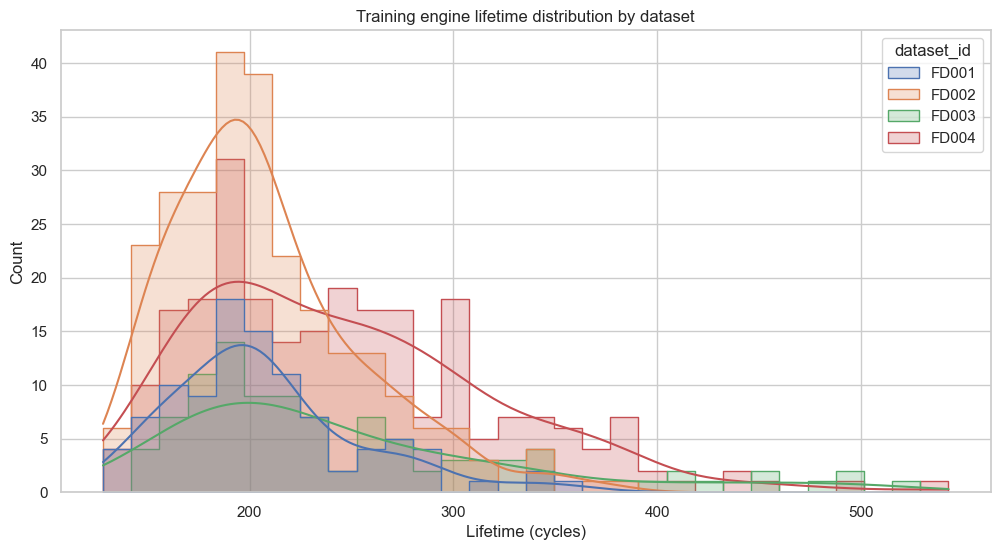

In [54]:
plt.figure(figsize=(12, 6))
sns.histplot(data=train_lifetimes, x="lifetime", hue="dataset_id", bins=30, kde=True, element="step")
plt.title("Training engine lifetime distribution by dataset")
plt.xlabel("Lifetime (cycles)")
plt.ylabel("Count")
plt.show()

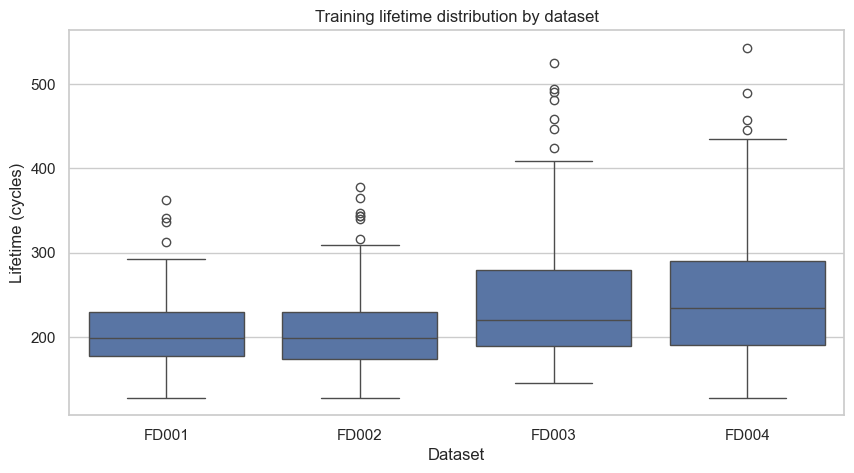

In [55]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=train_lifetimes, x="dataset_id", y="lifetime")
plt.title("Training lifetime distribution by dataset")
plt.xlabel("Dataset")
plt.ylabel("Lifetime (cycles)")
plt.show()

## 7. Sensor variance analysis: useful vs useless sensors

For identifying:

- nearly constant sensors
- very low-variance sensors
- sensors that visibly change with degradation

Low-variance or constant sensors are not useful for modeling.

In [56]:
sensor_variance = train_df[sensor_cols].var().sort_values(ascending=False).rename("variance").reset_index()
sensor_variance.columns = ["sensor", "variance"]
sensor_variance

,sensor,variance
0,s9,140368.207553
1,s7,30322.592497
2,s12,26959.499018
3,s18,20309.987770
4,s8,20285.340176
5,s4,18577.709837
6,s3,13965.392208
7,s13,12358.155761
8,s14,6500.109571
9,s2,1804.424361


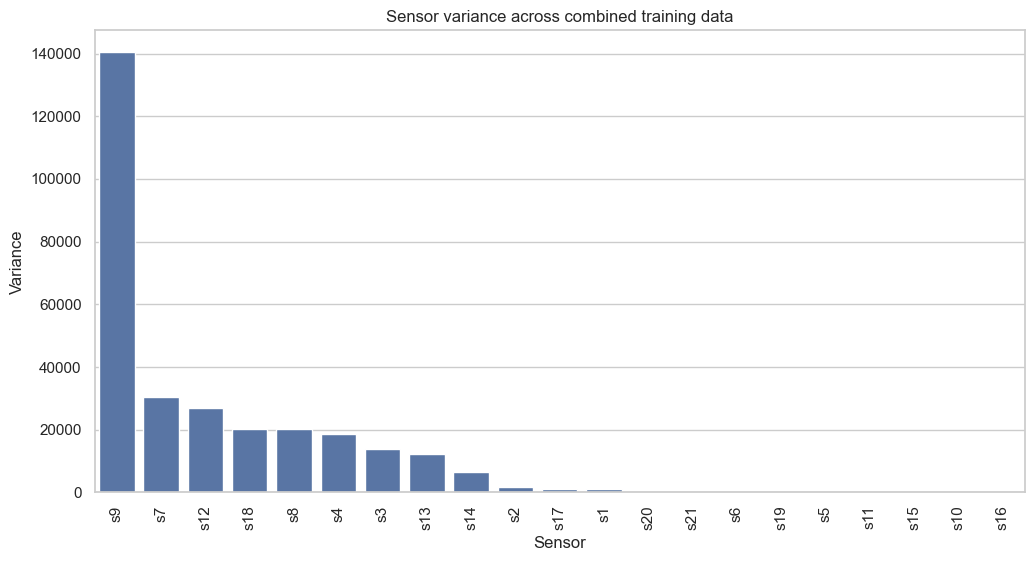

In [57]:
plt.figure(figsize=(12, 6))
sns.barplot(data=sensor_variance, x="sensor", y="variance")
plt.xticks(rotation=90)
plt.title("Sensor variance across combined training data")
plt.xlabel("Sensor")
plt.ylabel("Variance")
plt.show()

In [58]:
low_variance_threshold = sensor_variance["variance"].quantile(0.25)

low_variance_sensors = sensor_variance.query("variance <= @low_variance_threshold")["sensor"].tolist()
high_variance_sensors = sensor_variance.query("variance > @low_variance_threshold")["sensor"].tolist()

print("Low-variance sensors (candidate less-useful sensors):")
print(low_variance_sensors)
print("\nHigher-variance sensors (candidate useful sensors):")
print(high_variance_sensors)

Low-variance sensors (candidate less-useful sensors):
['s19', 's5', 's11', 's15', 's10', 's16']

Higher-variance sensors (candidate useful sensors):
['s9', 's7', 's12', 's18', 's8', 's4', 's3', 's13', 's14', 's2', 's17', 's1', 's20', 's21', 's6']


## 8. Sensor distributions

Distributions for all 21 sensors, for identifying skewed sensors, narrow sensors and multimodal sensors.

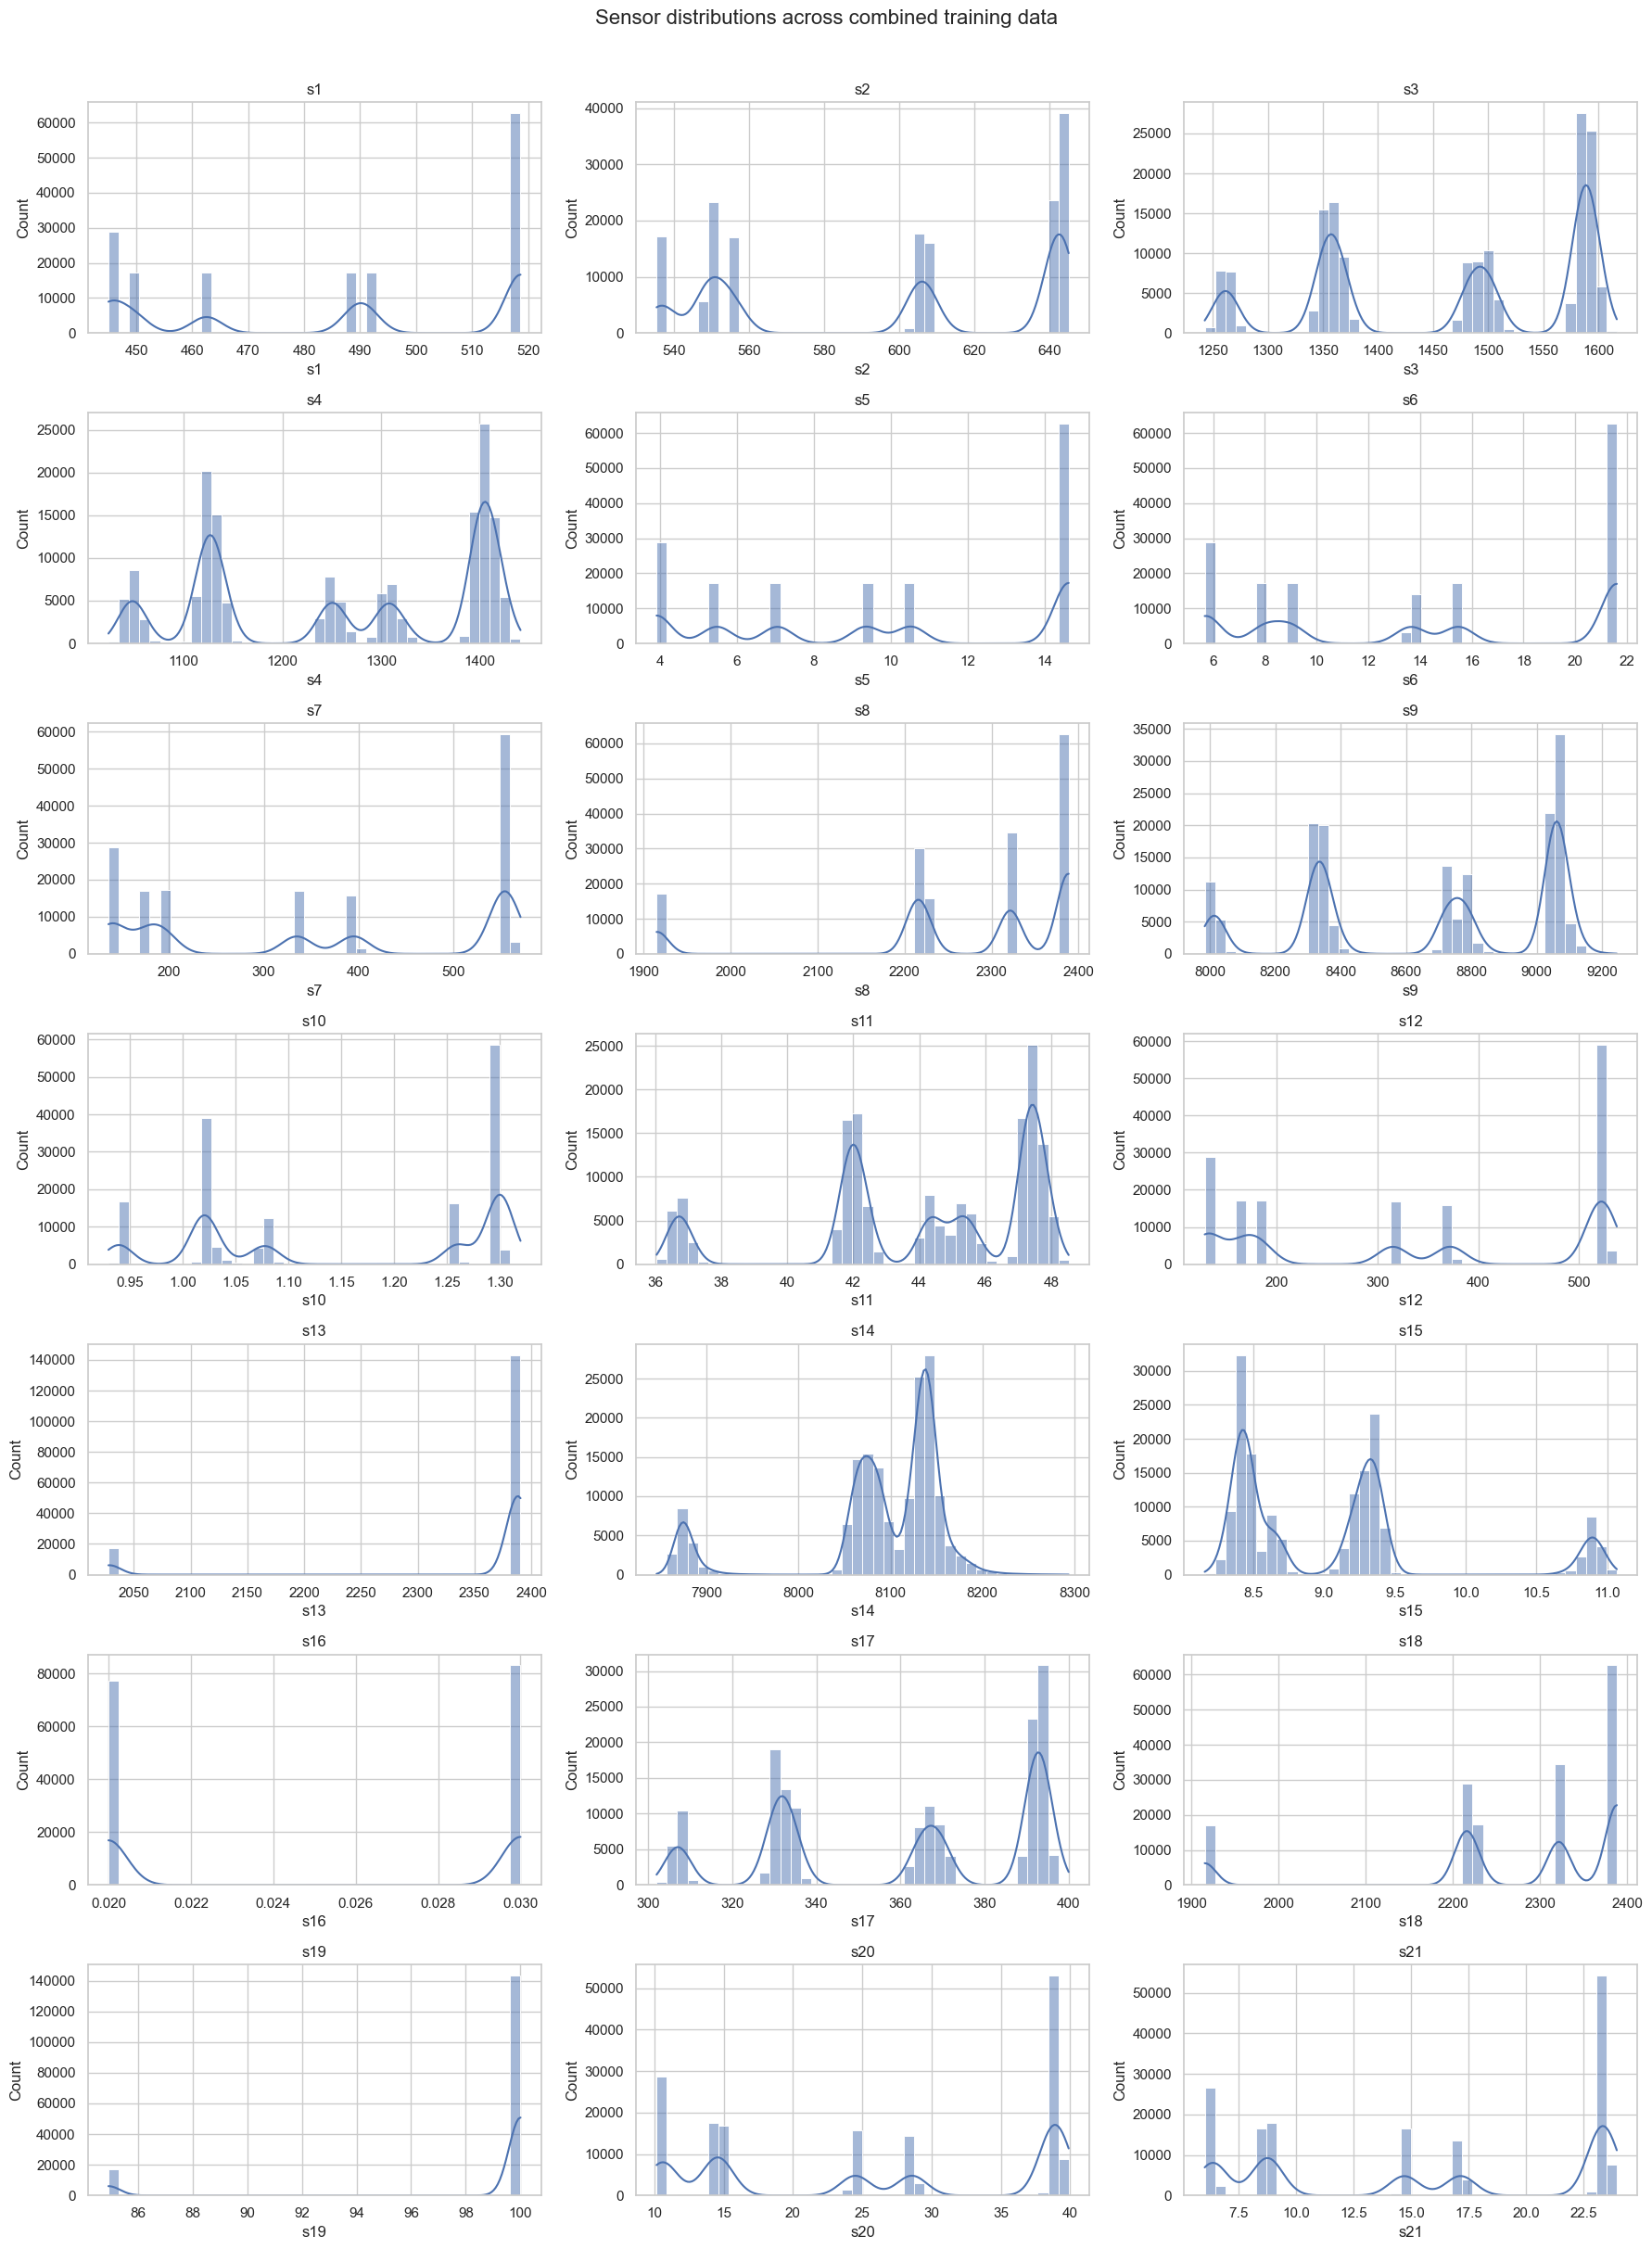

In [59]:
fig, axes = plt.subplots(7, 3, figsize=(18, 24))
axes = axes.flatten()

for ax, s in zip(axes, sensor_cols):
    sns.histplot(train_df[s], bins=40, kde=True, ax=ax)
    ax.set_title(s)

for ax in axes[len(sensor_cols):]:
    ax.axis("off")

plt.suptitle("Sensor distributions across combined training data", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## 9. Lifecycle plots

How does sensor values evolve over the lifecycle of engines?

Normalized lifecycle variable:

- `life_pct = cycle / engine_max_cycle`

This makes different engine lengths comparable.

In [60]:
engine_max = train_df.groupby(["dataset_id", "engine_id"])["cycle"].max().rename("engine_max_cycle")
train_life = train_df.merge(engine_max, on=["dataset_id", "engine_id"], how="left")
train_life["life_pct"] = train_life["cycle"] / train_life["engine_max_cycle"]

train_life[["dataset_id", "engine_id", "cycle", "engine_max_cycle", "life_pct", "RUL"]].head()

,dataset_id,engine_id,cycle,engine_max_cycle,life_pct,RUL
0,FD001,1,1,192,0.005208,191
1,FD001,1,2,192,0.010417,190
2,FD001,1,3,192,0.015625,189
3,FD001,1,4,192,0.020833,188
4,FD001,1,5,192,0.026042,187


In [61]:
# Average sensor trajectory over normalized lifetime
life_bins = np.linspace(0, 1, 21)
train_life["life_bin"] = pd.cut(train_life["life_pct"], bins=life_bins, include_lowest=True)

avg_lifecycle = (
    train_life.groupby(["dataset_id", "life_bin"])[sensor_cols]
    .mean(numeric_only=True)
    .reset_index()
)

avg_lifecycle["life_bin_mid"] = avg_lifecycle["life_bin"].apply(lambda x: x.mid)
avg_lifecycle.head()

,dataset_id,life_bin,s1,s2,s3,s4,s5,s6,s7,s8,s9,s10,s11,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21,life_bin_mid
0,FD001,"(-0.001, 0.05]",518.67,642.359898,1586.714734,1402.453885,14.62,21.609448,553.980511,2388.056258,9056.068415,1.3,47.342004,521.939029,2388.053272,8137.538793,8.417404,0.03,392.215746,2388.0,100.0,38.940654,23.364710,0.0245
1,FD001,"(0.05, 0.1]",518.67,642.382425,1586.706862,1402.615958,14.62,21.609538,553.968200,2388.056073,9056.158325,1.3,47.351280,521.921521,2388.054957,8137.616275,8.416942,0.03,392.275265,2388.0,100.0,38.932993,23.361398,0.0750
2,FD001,"(0.1, 0.15]",518.67,642.374197,1587.026402,1402.643588,14.62,21.609642,553.944168,2388.059884,9056.223056,1.3,47.354004,521.905561,2388.056799,8137.270774,8.418103,0.03,392.271760,2388.0,100.0,38.929371,23.359454,0.1250
3,FD001,"(0.15, 0.2]",518.67,642.395063,1586.922502,1402.958512,14.62,21.609536,553.935845,2388.058184,9056.406126,1.3,47.358773,521.900792,2388.059159,8137.694734,8.418887,0.03,392.244444,2388.0,100.0,38.933778,23.358388,0.1750
4,FD001,"(0.2, 0.25]",518.67,642.389651,1587.174302,1403.189845,14.62,21.609661,553.903537,2388.059719,9056.915310,1.3,47.365795,521.879913,2388.059399,8137.905291,8.419830,0.03,392.349806,2388.0,100.0,38.928934,23.350419,0.2250


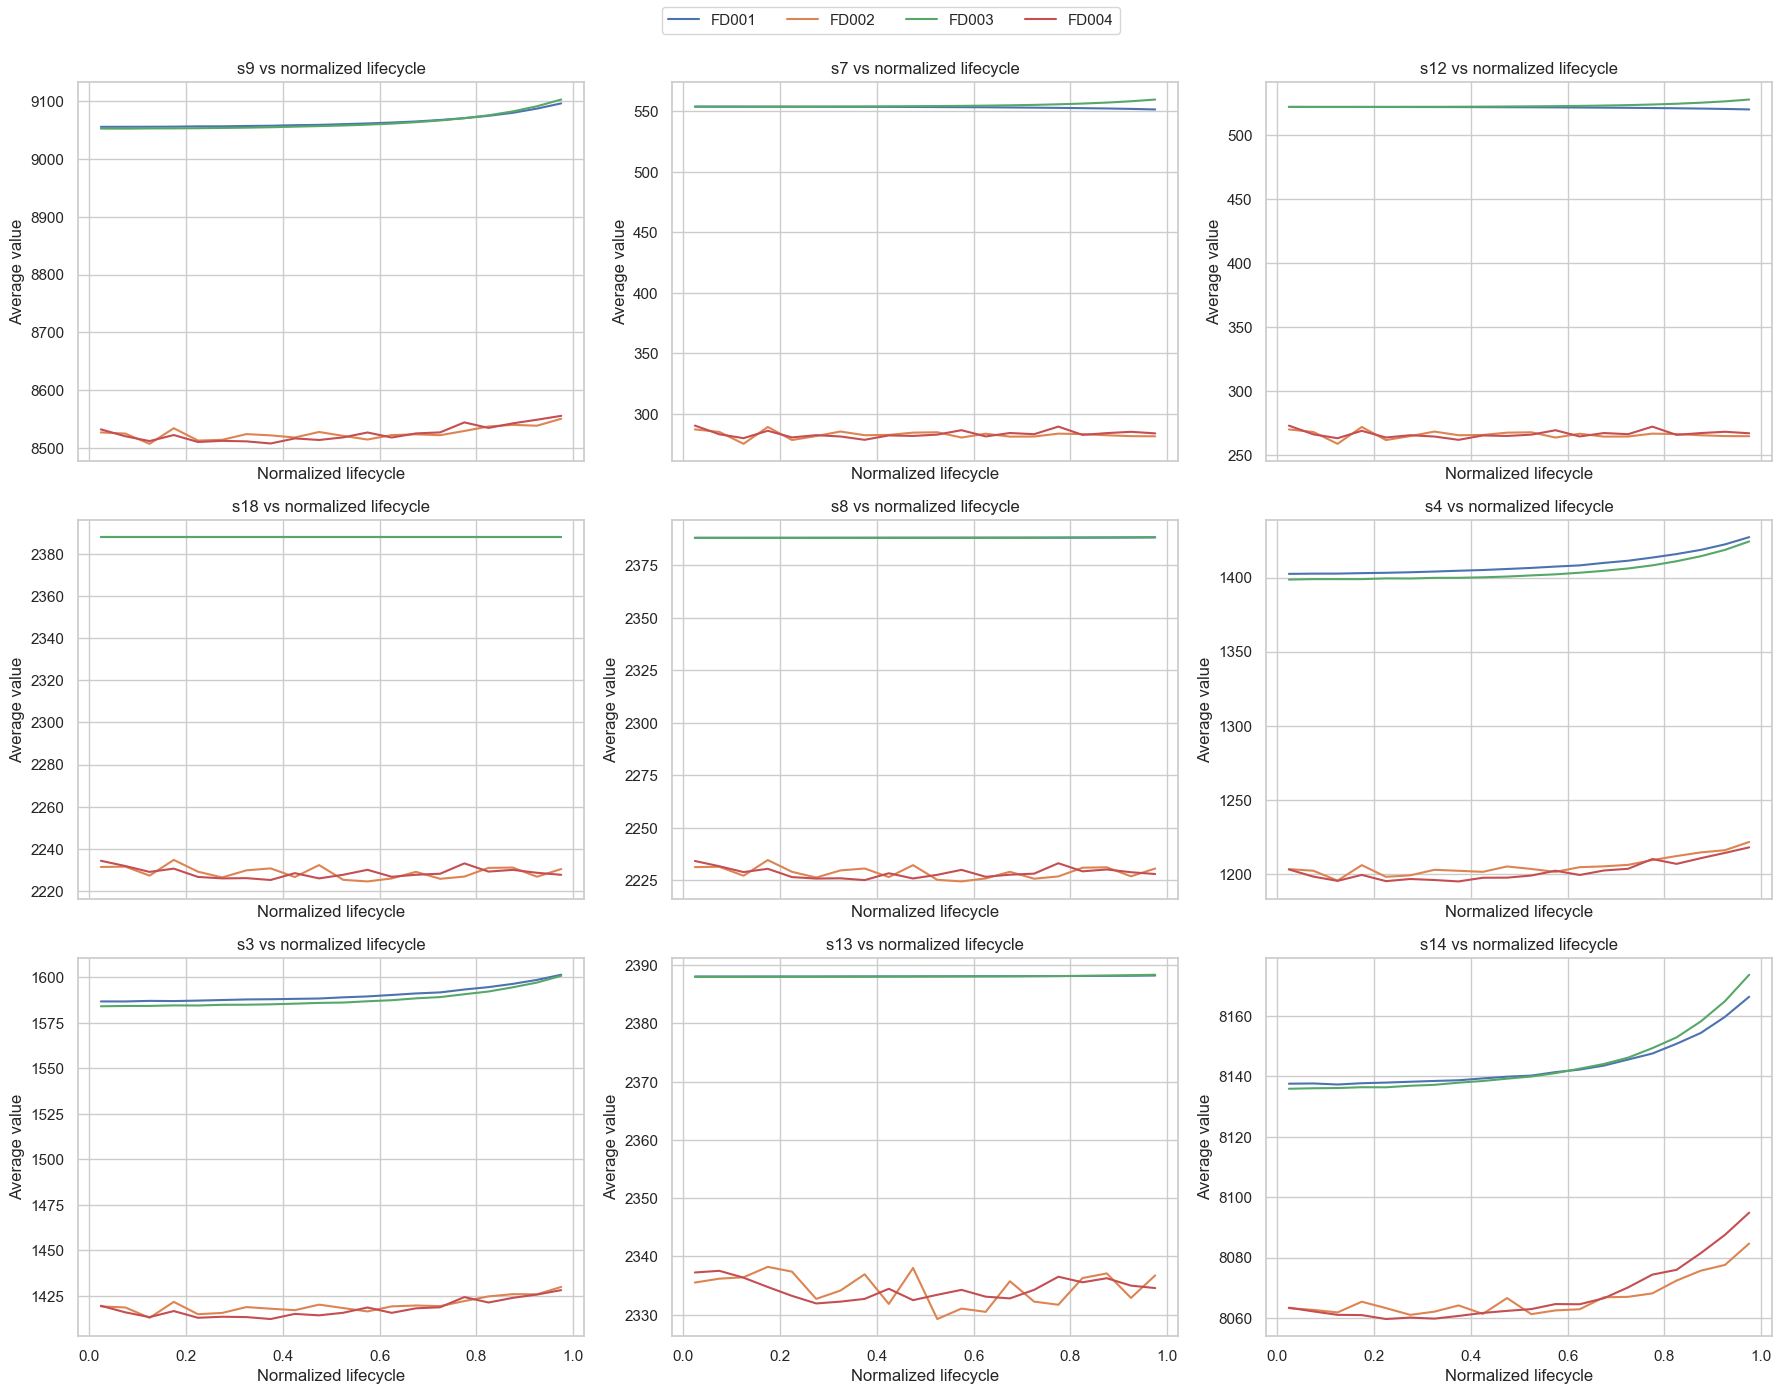

In [62]:
top_dynamic_sensors = sensor_variance.head(9)["sensor"].tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharex=True)
axes = axes.flatten()

for ax, s in zip(axes, top_dynamic_sensors):
    for fd in ["FD001", "FD002", "FD003", "FD004"]:
        tmp = avg_lifecycle[avg_lifecycle["dataset_id"] == fd]
        ax.plot(tmp["life_bin_mid"], tmp[s], label=fd)
    ax.set_title(f"{s} vs normalized lifecycle")
    ax.set_xlabel("Normalized lifecycle")
    ax.set_ylabel("Average value")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 10. Correlation matrix

We compute the sensor-to-sensor correlation matrix on the training data.
This helps identify redundant sensors and strongly coupled sensor groups.

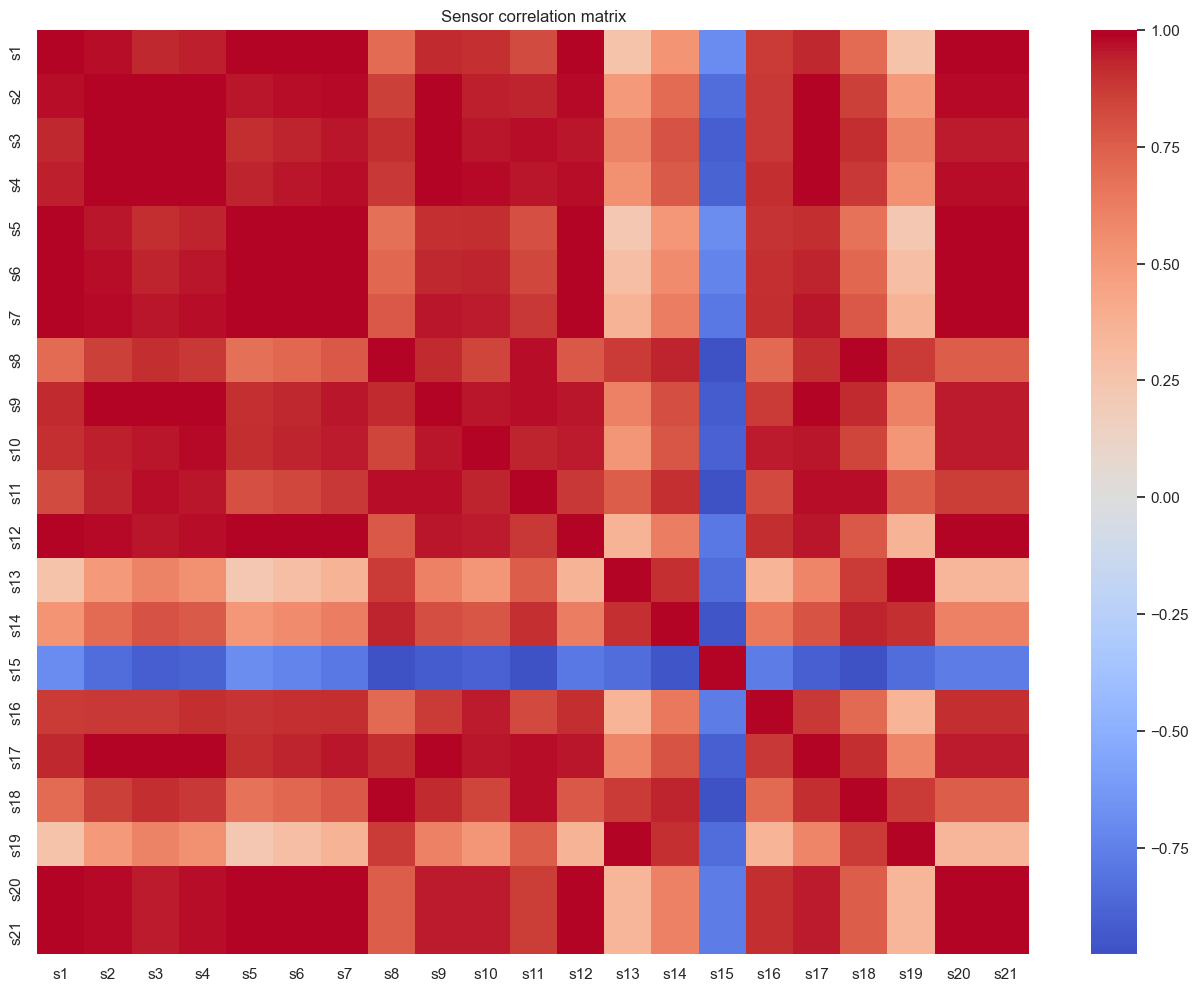

In [63]:
corr = train_df[sensor_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Sensor correlation matrix")
plt.show()

In [64]:
# Highest absolute off-diagonal correlations
corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["sensor_1", "sensor_2", "correlation"]
corr_pairs["abs_corr"] = corr_pairs["correlation"].abs()
corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

# Remove symmetric duplicates
corr_pairs["pair_key"] = corr_pairs.apply(lambda r: tuple(sorted([r["sensor_1"], r["sensor_2"]])), axis=1)
corr_pairs = corr_pairs.drop_duplicates("pair_key").drop(columns="pair_key")

corr_pairs.head(20)

,sensor_1,sensor_2,correlation,abs_corr
164,s8,s18,0.999999,0.999999
390,s19,s13,0.999998,0.999998
237,s12,s7,0.999995,0.999995
419,s20,s21,0.999927,0.999927
145,s7,s20,0.999511,0.999511
426,s21,s7,0.999511,0.999511
410,s20,s12,0.999479,0.999479
251,s12,s21,0.999479,0.999479
58,s3,s17,0.998944,0.998944
184,s9,s17,0.998370,0.998370


## 11. Linear Relationship with RUL

This section gives a quick ranking of sensors by their linear association with the training RUL target.

In [65]:
rul_corr = (
    train_df[sensor_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .sort_values(key=np.abs, ascending=False)
    .rename("corr_with_RUL")
    .reset_index()
)
rul_corr.columns = ["sensor", "corr_with_RUL"]
rul_corr

,sensor,corr_with_RUL
0,s14,-0.064813
1,s11,-0.044859
2,s4,-0.032047
3,s16,-0.031191
4,s15,-0.028528
5,s17,-0.020581
6,s3,-0.020455
7,s20,0.014697
8,s21,0.014656
9,s9,-0.011261


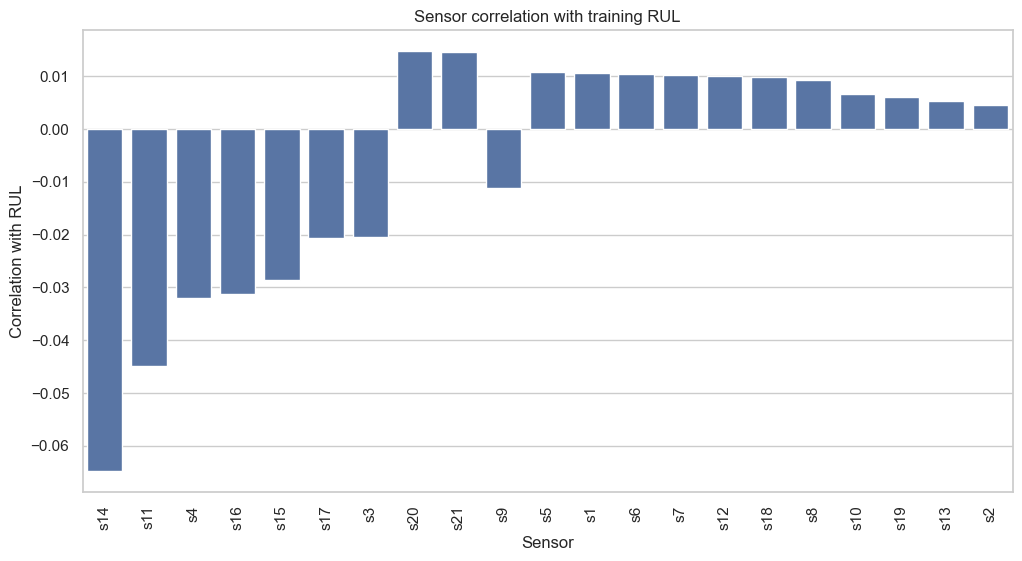

In [66]:
plt.figure(figsize=(12, 6))
sns.barplot(data=rul_corr, x="sensor", y="corr_with_RUL")
plt.xticks(rotation=90)
plt.title("Sensor correlation with training RUL")
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.show()

## 12. Dataset-specific sensor means

This helps show how datasets differ overall, especially because some subsets contain more operating regimes and/or fault modes.

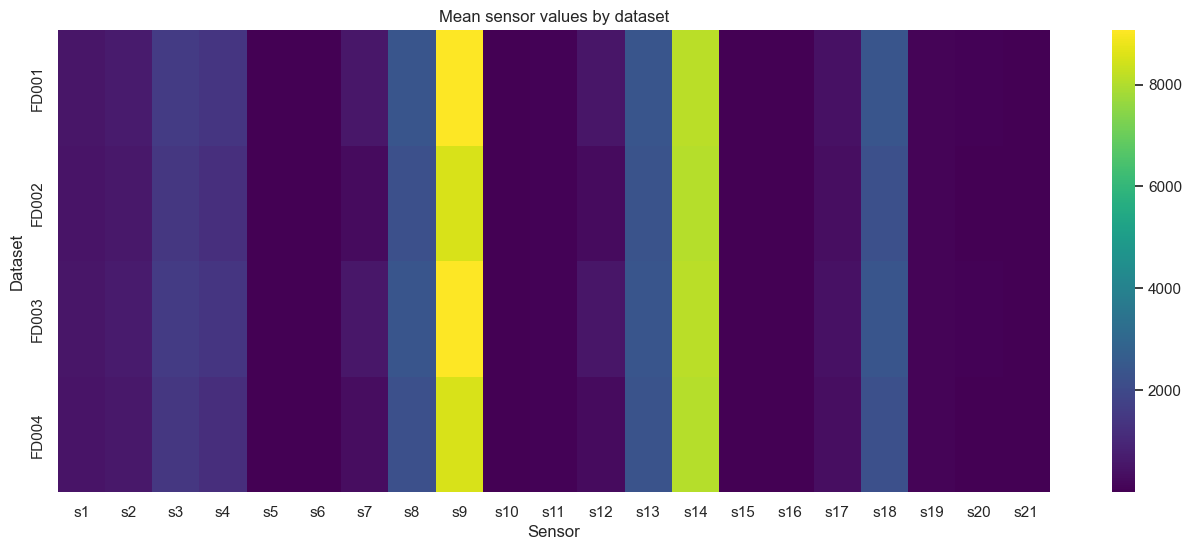

In [74]:
dataset_sensor_means = train_df.groupby("dataset_id")[sensor_cols].mean()
plt.figure(figsize=(16, 6))
sns.heatmap(dataset_sensor_means, cmap="viridis")
plt.title("Mean sensor values by dataset")
plt.xlabel("Sensor")
plt.ylabel("Dataset")
plt.show()

## 13. Saving cleaned EDA summary tables

In [75]:
eda_outputs = {
    "summary_df.csv": summary_df,
    "train_lifetimes.csv": train_lifetimes,
    "sensor_variance.csv": sensor_variance,
    "sensor_rul_correlation.csv": rul_corr
}

save_outputs = True 

if save_outputs:
    out_dir = BASE_DIR / "eda_outputs"
    out_dir.mkdir(exist_ok=True)
    for name, df in eda_outputs.items():
        df.to_csv(out_dir / name, index=False)
    print("Saved outputs to:", out_dir)
else:
    print("save_outputs=False, so no files were written.")

Saved outputs to: d:\NASA\eda_outputs
